# Bayesian Network with SMOTE for COVID-19 diagnosis: temporal validation

This notebook reproduces all results of the paper *Uncertainty-Aware Bayesian Network Diagnosis for Imbalanced Pandemic Data: A COVID-19 Case Study*.

Both datasets come from the CovidPred repository of Zoabi et al. (https://github.com/nshomron/covidpred):

| File | Downloaded | Test dates |
|---|---|---|
| `corona_tested_individuals_ver_006.english.csv.zip` | 4 May 2020 | 11 Mar 2020 to 30 Apr 2020 |
| `corona_tested_individuals_ver_0083.english.csv.zip` | 15 Nov 2020 | 11 Mar 2020 to 12 Nov 2020 |

`ver_0083` is a later copy of the same national testing data, so it already contains the period covered by `ver_006`. To avoid testing on records the model has seen, the design is:

* **Development data:** `ver_006` (11 Mar to 30 Apr 2020), split 80/20 into a training set and an internal test set.
* **Temporal validation data:** only the `ver_0083` records tested **after 30 Apr 2020** (1 May to 12 Nov 2020). No record from this period is used for training.

SMOTE is applied to the training set only. Both test sets keep their real class ratio.

Outputs are written to `results/` (CSV files) and `figures/` (PNG files).

In [1]:
import os, time, zipfile, urllib.request, logging, warnings, platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

import imblearn
from imblearn.over_sampling import SMOTEN

import pgmpy
try:
    from pgmpy.models import DiscreteBayesianNetwork as BayesianNetwork   # pgmpy >= 1.0
except ImportError:
    from pgmpy.models import BayesianNetwork                               # older pgmpy
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

logging.getLogger("pgmpy").setLevel(logging.WARNING)
warnings.filterwarnings("ignore")

SEED = 42
DATA_DIR, RESULTS_DIR, FIG_DIR = "data", "results", "figures"
for d in (DATA_DIR, RESULTS_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

FEATURES = ["cough", "fever", "sore_throat", "shortness_of_breath", "head_ache",
            "age_60_and_above", "gender", "test_indication"]
SYMPTOMS = FEATURES[:5]
TARGET = "corona_result"
CUTOFF = "2020-04-30"          # last test date in ver_006

plt.rcParams["font.family"] = "DejaVu Sans"   # matplotlib default font, as in the paper figures
# colours used in the paper figures
C_BN, C_BN0, C_LR, C_KNN, C_RF = "#4C72B0", "#8C8C8C", "#FF7F0E", "#2CA02C", "#D62728"

print("python", platform.python_version(), "| pandas", pd.__version__, "| numpy", np.__version__,
      "| scikit-learn", sklearn.__version__, "| imbalanced-learn", imblearn.__version__,
      "| pgmpy", getattr(pgmpy, "__version__", "unknown"),
      "| matplotlib", matplotlib.__version__)

python 3.13.15 | pandas 3.0.5 | numpy 2.5.3 | scikit-learn 1.9.1 | imbalanced-learn 0.15.dev0 | pgmpy 1.0.0 | matplotlib 3.11.2


## 1. Load the two dataset versions
If the zip files are not in `data/`, they are downloaded from the GitHub repository.

In [2]:
REPO = "https://github.com/nshomron/covidpred/raw/master/data/"
FILES = {"ver_006": "corona_tested_individuals_ver_006.english.csv.zip",
         "ver_0083": "corona_tested_individuals_ver_0083.english.csv.zip"}

def load_version(fname):
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        print("downloading", fname)
        urllib.request.urlretrieve(REPO + fname, path)
    with zipfile.ZipFile(path) as z:
        member = [n for n in z.namelist() if n.endswith(".csv") and not n.startswith("__MACOSX")][0]
        with z.open(member) as f:
            return pd.read_csv(f, na_values=["None"], low_memory=False)

v006 = load_version(FILES["ver_006"])
v0083 = load_version(FILES["ver_0083"])

for name, d in [("ver_006", v006), ("ver_0083", v0083)]:
    print(f"{name}: {len(d):,} records, test dates {d.test_date.min()} to {d.test_date.max()}")

ver_006: 278,848 records, test dates 2020-03-11 to 2020-04-30
ver_0083: 2,742,596 records, test dates 2020-03-11 to 2020-11-12


### Overlap between the two versions
Records per test date. Up to 30 April both files hold almost the same records (small differences come from later updates of the registry), so `ver_0083` cannot be used as a whole for validation.

In [3]:
per_day = pd.concat([v006.groupby("test_date").size().rename("ver_006"),
                     v0083.groupby("test_date").size().rename("ver_0083")], axis=1).fillna(0).astype(int)
per_day.to_csv(f"{RESULTS_DIR}/records_per_test_date.csv")

up_to = per_day[per_day.index <= CUTOFF]
after = per_day[per_day.index > CUTOFF]
print(f"Up to {CUTOFF}:  ver_006 = {up_to.ver_006.sum():,}   ver_0083 = {up_to.ver_0083.sum():,}")
print(f"After {CUTOFF}:  ver_006 = {after.ver_006.sum():,}   ver_0083 = {after.ver_0083.sum():,}")
per_day.loc["2020-04-25":"2020-05-05"]

Up to 2020-04-30:  ver_006 = 278,848   ver_0083 = 289,218
After 2020-04-30:  ver_006 = 0   ver_0083 = 2,453,378


,ver_006,ver_0083
test_date,,
2020-04-25,5052,4851
2020-04-26,6131,7417
2020-04-27,7304,7084
2020-04-28,6334,6100
2020-04-29,4259,4659
2020-04-30,7313,6676
2020-05-01,0,5884
2020-05-02,0,2429
2020-05-03,0,5954


## 2. Development and temporal validation sets

In [4]:
dev_raw = v006.copy()
val_raw = v0083[v0083.test_date > CUTOFF].copy()

def class_table(d):
    c = d[TARGET].value_counts().reindex(["negative", "positive", "other"])
    return pd.DataFrame({"count": c, "percent": (100 * c / c.sum()).round(2)})

class_dist = pd.concat([class_table(dev_raw).add_prefix("development_"),
                        class_table(val_raw).add_prefix("temporal_validation_")], axis=1)
class_dist.index.name = "corona_result"
class_dist.to_csv(f"{RESULTS_DIR}/table1_class_distribution.csv")
print(f"development: {len(dev_raw):,} records ({dev_raw.test_date.min()} to {dev_raw.test_date.max()})")
print(f"temporal validation: {len(val_raw):,} records ({val_raw.test_date.min()} to {val_raw.test_date.max()})")
class_dist

development: 278,848 records (2020-03-11 to 2020-04-30)
temporal validation: 2,453,378 records (2020-05-01 to 2020-11-12)


,development_count,development_percent,temporal_validation_count,temporal_validation_percent
corona_result,,,,
negative,260227,93.32,2209772,90.07
positive,14729,5.28,206286,8.41
other,3892,1.40,37320,1.52


## 3. Preprocessing
* records with result `other` are removed,
* records with missing symptom values are removed,
* categorical values are mapped to numbers (same mapping as in the paper),
* `test_date` is **not** used as a model input. In a temporal validation the dates of the validation period never occur in training, so it is used only to split the data in time.

In [5]:
MAPS = {TARGET: {"negative": 0, "positive": 1},
        "age_60_and_above": {"No": 0, "Yes": 1},
        "gender": {"female": 0, "male": 1},
        "test_indication": {"Contact with confirmed": 1, "Abroad": 2, "Other": 3}}

def preprocess(d):
    d = d[d[TARGET] != "other"].copy()
    n_before = len(d)
    d = d.dropna(subset=SYMPTOMS)
    for col, m in MAPS.items():
        d[col] = d[col].map(m)
    for col in SYMPTOMS + [TARGET, "test_indication"]:
        d[col] = d[col].astype(int)
    print(f"  removed {n_before - len(d):,} records with missing symptoms, kept {len(d):,}")
    return d[["test_date"] + FEATURES + [TARGET]].reset_index(drop=True)

print("development:"); dev = preprocess(dev_raw)
print("temporal validation:"); val = preprocess(val_raw)

missing = pd.DataFrame({
    "development_missing": dev[["age_60_and_above", "gender"]].isna().sum(),
    "development_missing_%": (100 * dev[["age_60_and_above", "gender"]].isna().mean()).round(2),
    "validation_missing": val[["age_60_and_above", "gender"]].isna().sum(),
    "validation_missing_%": (100 * val[["age_60_and_above", "gender"]].isna().mean()).round(2)})
missing.to_csv(f"{RESULTS_DIR}/missing_values.csv")
missing

development:
  removed 254 records with missing symptoms, kept 274,702
temporal validation:
  removed 0 records with missing symptoms, kept 2,416,058


,development_missing,development_missing_%,validation_missing,validation_missing_%
age_60_and_above,125659,45.74,408713,16.92
gender,19034,6.93,87865,3.64


### Train / internal test split
Stratified 80/20 split of the development data. The split is done **before** imputation and SMOTE so that nothing from the internal test set leaks into training.

In [6]:
train, test = train_test_split(dev, test_size=0.2, stratify=dev[TARGET], random_state=SEED)
train, test = train.reset_index(drop=True), test.reset_index(drop=True)
for name, d in [("train", train), ("internal test", test), ("temporal validation", val)]:
    print(f"{name:20s} {len(d):>9,} records   positive = {d[TARGET].sum():>7,} ({100 * d[TARGET].mean():.2f}%)")

train                  219,761 records   positive =  11,755 (5.35%)
internal test           54,941 records   positive =   2,939 (5.35%)
temporal validation  2,416,058 records   positive = 206,286 (8.54%)


### Imputation of `age_60_and_above` and `gender`
As in the paper, missing values of these two features are predicted with linear regression. The regression uses the symptoms and the test indication (not the test result), is fitted on the training set only, and the prediction is rounded to 0 or 1.

In [7]:
def imp_design(d):
    X = d[SYMPTOMS].copy()
    X["ind_contact"] = (d["test_indication"] == 1).astype(int)
    X["ind_abroad"] = (d["test_indication"] == 2).astype(int)
    return X

imputers = {}
for col in ["age_60_and_above", "gender"]:
    known = train[col].notna()
    imputers[col] = LinearRegression().fit(imp_design(train[known]), train.loc[known, col])

imp_log = []
def impute(d, name):
    d = d.copy()
    for col, reg in imputers.items():
        miss = d[col].isna()
        if miss.any():
            pred = (reg.predict(imp_design(d[miss])) >= 0.5).astype(int)
            d.loc[miss, col] = pred
            imp_log.append({"set": name, "feature": col, "imputed": int(miss.sum()),
                            "imputed_as_1": int(pred.sum())})
        d[col] = d[col].astype(int)
    return d

val_age_missing = val["age_60_and_above"].isna().to_numpy()   # kept for the monthly table
train, test, val = impute(train, "train"), impute(test, "internal test"), impute(val, "temporal validation")
imp_log = pd.DataFrame(imp_log)
imp_log.to_csv(f"{RESULTS_DIR}/imputation_summary.csv", index=False)
imp_log

,set,feature,imputed,imputed_as_1
0,train,age_60_and_above,100425,0
1,train,gender,15268,2687
2,internal test,age_60_and_above,25234,0
3,internal test,gender,3766,639
4,temporal validation,age_60_and_above,408713,0
5,temporal validation,gender,87865,3066


## 4. SMOTE on the training set only
All eight inputs are binary or categorical, so ordinary SMOTE interpolation would create values such as `cough = 0.37` or a test indication between two categories. We therefore use **SMOTE-N**, the nominal version of SMOTE from the same paper by Chawla et al. (2002). It finds neighbours with the value difference metric and gives each feature of a synthetic record the most frequent value among the neighbours.

In [8]:
X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]
X_val, y_val = val[FEATURES], val[TARGET]

t0 = time.perf_counter()
X_sm, y_sm = SMOTEN(k_neighbors=5, random_state=SEED).fit_resample(X_train, y_train)
smote_time = time.perf_counter() - t0
X_sm = pd.DataFrame(X_sm, columns=FEATURES).astype(int)
y_sm = pd.Series(y_sm, name=TARGET).astype(int)

# SMOTE appends all synthetic positives at the end of the data. The rows are shuffled so that
# order-dependent steps (for example tie-breaking between identical neighbours in KNN) are not biased.
perm = np.random.default_rng(SEED).permutation(len(y_sm))
X_sm, y_sm = X_sm.iloc[perm].reset_index(drop=True), y_sm.iloc[perm].reset_index(drop=True)

smote_counts = pd.DataFrame({"before_SMOTE": y_train.value_counts().sort_index(),
                             "after_SMOTE": y_sm.value_counts().sort_index()})
smote_counts.index = ["negative (0)", "positive (1)"]
smote_counts.to_csv(f"{RESULTS_DIR}/smote_class_counts.csv")
print(f"SMOTE-N time: {smote_time:.1f} s")
smote_counts

SMOTE-N time: 43.2 s


,before_SMOTE,after_SMOTE
negative (0),208006,208006
positive (1),11755,208006


## 5. Models
**Bayesian Network:** every feature node points to `corona_result` (same structure as the paper, without the test date node). Parameters are estimated with Maximum Likelihood and inference uses Variable Elimination.

Because all inputs are discrete, many records share exactly the same combination of feature values. For every model, the prediction is computed once for each distinct combination and mapped back to the records. This gives exactly the same predictions as predicting record by record and it is how pgmpy's own `predict` works.

Baselines (same as the paper): Logistic Regression, KNN and Random Forest, trained on the same SMOTE-balanced data. A Bayesian Network trained **without** SMOTE is added to show the effect of SMOTE.

The decision threshold is 0.5 for all models. Times are measured as training time + prediction time on the internal test set; each model is run 5 times and the mean time is reported.

In [9]:
EDGES = [(f, TARGET) for f in FEATURES]

def fit_bn(X, y):
    data = X.copy()
    data[TARGET] = np.asarray(y)
    model = BayesianNetwork(EDGES)
    model.fit(data, estimator=MaximumLikelihoodEstimator)
    return model

def bn_proba(model, combos):
    infer = VariableElimination(model)
    out = []
    for row in combos.itertuples(index=False):
        q = infer.query([TARGET], evidence=dict(zip(FEATURES, map(int, row))), show_progress=False)
        out.append(q.get_value(**{TARGET: 1}))
    return np.array(out)

def sk_proba(model, combos):
    return model.predict_proba(combos)[:, 1]

def predict_unique(model, proba_fn, X):
    combos = X.drop_duplicates().reset_index(drop=True)
    combos["p"] = proba_fn(model, combos[FEATURES])
    return X.merge(combos, on=FEATURES, how="left")["p"].to_numpy()

MODELS = {
    "Proposed BN":         (lambda: fit_bn(X_sm, y_sm), bn_proba),
    "BN without SMOTE":    (lambda: fit_bn(X_train, y_train), bn_proba),
    "Logistic Regression": (lambda: LogisticRegression(max_iter=1000).fit(X_sm, y_sm), sk_proba),
    "KNN":                 (lambda: KNeighborsClassifier(n_neighbors=5).fit(X_sm, y_sm), sk_proba),
    "Random Forest":       (lambda: RandomForestClassifier(n_estimators=100, random_state=SEED).fit(X_sm, y_sm), sk_proba),
}

N_REPEAT = 5
fitted, p_test, times = {}, {}, {}
for name, (fit, proba_fn) in MODELS.items():
    t_fit, t_pred = [], []
    for _ in range(N_REPEAT):
        t0 = time.perf_counter()
        m = fit()
        t1 = time.perf_counter()
        p = predict_unique(m, proba_fn, X_test)
        t2 = time.perf_counter()
        t_fit.append(t1 - t0); t_pred.append(t2 - t1)
    fitted[name], p_test[name] = m, p
    tot = np.add(t_fit, t_pred)
    times[name] = {"train_s": np.mean(t_fit), "predict_s": np.mean(t_pred),
                   "total_s": tot.mean(), "total_sd": tot.std(ddof=1)}
    print(f"{name:20s} train {np.mean(t_fit):7.3f} s   predict {np.mean(t_pred):6.3f} s   "
          f"total {tot.mean():7.3f} s (sd {tot.std(ddof=1):.3f})")

Proposed BN          train   0.113 s   predict  0.065 s   total   0.178 s (sd 0.008)
BN without SMOTE     train   0.064 s   predict  0.064 s   total   0.128 s (sd 0.004)
Logistic Regression  train   0.838 s   predict  0.016 s   total   0.855 s (sd 0.059)
KNN                  train   0.498 s   predict  0.062 s   total   0.559 s (sd 0.010)
Random Forest        train   5.988 s   predict  0.021 s   total   6.009 s (sd 0.061)


## 6. Internal test set (development period, real class ratio) - Table 3 of the paper
Precision, recall (sensitivity), specificity and F1 are computed for the **positive class** with Eqs. (3) to (8) of the paper. AUC is computed from the predicted probabilities.

In [10]:
METRICS = ["Accuracy", "Precision", "Recall (Sensitivity)", "Specificity", "F1-score", "AUC"]

def evaluate(y, p, thr=0.5):
    y = np.asarray(y)
    yhat = (p > thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0, 1]).ravel()
    return {"Accuracy": (tp + tn) / (tp + tn + fp + fn),
            "Precision": tp / (tp + fp) if tp + fp else 0.0,
            "Recall (Sensitivity)": tp / (tp + fn),
            "Specificity": tn / (tn + fp),
            "F1-score": 2 * tp / (2 * tp + fp + fn),
            "AUC": roc_auc_score(y, p),
            "TP": tp, "FP": fp, "TN": tn, "FN": fn}

internal = pd.DataFrame({name: evaluate(y_test, p) for name, p in p_test.items()})
internal.loc["Total Time (s)"] = [times[n]["total_s"] for n in internal.columns]
internal.to_csv(f"{RESULTS_DIR}/table3_internal_test_metrics.csv")
pd.DataFrame(times).T.to_csv(f"{RESULTS_DIR}/model_times.csv")
internal.loc[METRICS + ["Total Time (s)"]].astype(float).round(4)

,Proposed BN,BN without SMOTE,Logistic Regression,KNN,Random Forest
Accuracy,0.9127,0.9677,0.8753,0.9127,0.9071
Precision,0.3559,0.7899,0.2704,0.3560,0.3412
Recall (Sensitivity),0.7802,0.5410,0.7836,0.7805,0.7914
Specificity,0.9202,0.9919,0.8805,0.9202,0.9136
F1-score,0.4888,0.6422,0.4020,0.4890,0.4768
AUC,0.9011,0.9015,0.8867,0.8921,0.9013
Total Time (s),0.1782,0.1281,0.8548,0.5591,6.0092


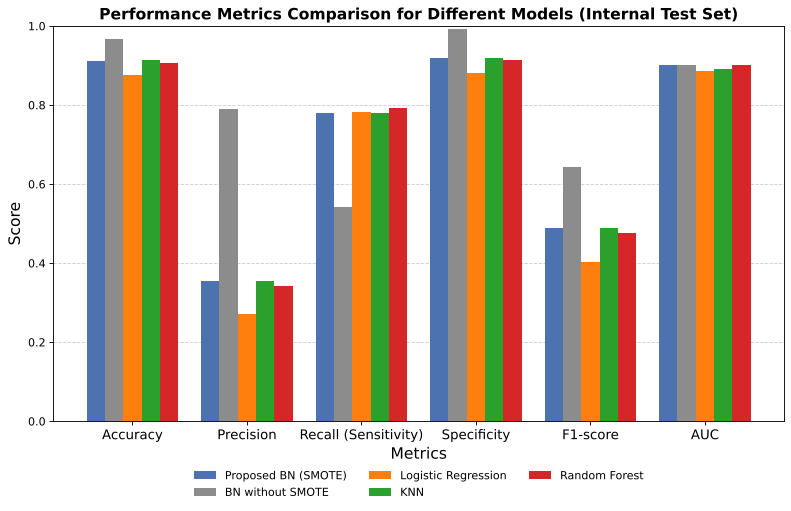

In [11]:
order = ["Proposed BN", "BN without SMOTE", "Logistic Regression", "KNN", "Random Forest"]
colors = [C_BN, C_BN0, C_LR, C_KNN, C_RF]
labels = ["Proposed BN (SMOTE)", "BN without SMOTE", "Logistic Regression", "KNN", "Random Forest"]

fig, ax = plt.subplots(figsize=(10, 6.5))
x = np.arange(len(METRICS)); w = 0.16
for i, (m, c, lab) in enumerate(zip(order, colors, labels)):
    ax.bar(x + (i - 2) * w, internal.loc[METRICS, m].astype(float), w, color=c, label=lab)
ax.set_xticks(x); ax.set_xticklabels(METRICS, fontsize=12)
ax.set_ylim(0, 1); ax.set_ylabel("Score", fontsize=14); ax.set_xlabel("Metrics", fontsize=14)
ax.set_title("Performance Metrics Comparison for Different Models (Internal Test Set)", fontsize=14, fontweight="bold")
ax.yaxis.grid(True, linestyle="--", alpha=0.6); ax.set_axisbelow(True)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=10, frameon=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/performance_metrics_chart.png", dpi=300, bbox_inches="tight")
plt.show()

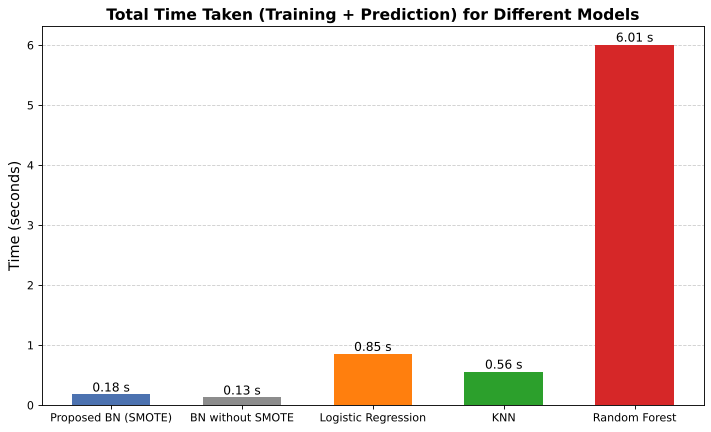

In [12]:
fig, ax = plt.subplots(figsize=(9, 5.5))
tot = [times[m]["total_s"] for m in order]
bars = ax.bar(labels, tot, color=colors, width=0.6)
for b, v in zip(bars, tot):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f} s", ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Time (seconds)", fontsize=13)
ax.set_title("Total Time Taken (Training + Prediction) for Different Models", fontsize=14, fontweight="bold")
ax.yaxis.grid(True, linestyle="--", alpha=0.6); ax.set_axisbelow(True)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/total_time_chart.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Temporal validation (1 May to 12 Nov 2020) - Table 4 of the paper
The trained models are applied, without any change, to the later records of `ver_0083`.

In [13]:
p_val = {name: predict_unique(fitted[name], MODELS[name][1], X_val) for name in order}
temporal = pd.DataFrame({name: evaluate(y_val, p) for name, p in p_val.items()})
temporal.to_csv(f"{RESULTS_DIR}/temporal_validation_all_models.csv")
temporal.loc[METRICS].astype(float).round(4)

,Proposed BN,BN without SMOTE,Logistic Regression,KNN,Random Forest
Accuracy,0.9340,0.9343,0.9347,0.9339,0.9340
Precision,0.6108,0.6400,0.6229,0.6100,0.6101
Recall (Sensitivity),0.6266,0.5271,0.5975,0.6250,0.6284
Specificity,0.9627,0.9723,0.9662,0.9627,0.9625
F1-score,0.6186,0.5781,0.6099,0.6174,0.6191
AUC,0.8177,0.8177,0.8122,0.8150,0.8177


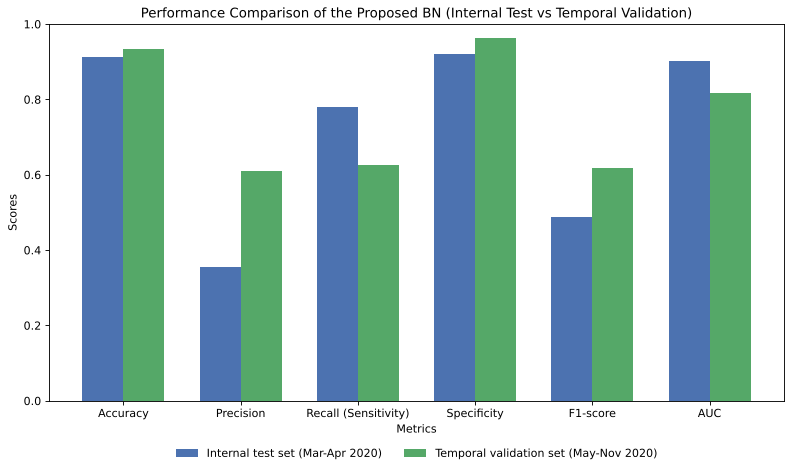

,Internal test (Mar-Apr 2020),Temporal validation (May-Nov 2020)
Accuracy,0.9127,0.9340
Precision,0.3559,0.6108
Recall (Sensitivity),0.7802,0.6266
Specificity,0.9202,0.9627
F1-score,0.4888,0.6186
AUC,0.9011,0.8177


In [14]:
bn_compare = pd.DataFrame({"Internal test (Mar-Apr 2020)": internal.loc[METRICS, "Proposed BN"].astype(float),
                       "Temporal validation (May-Nov 2020)": temporal.loc[METRICS, "Proposed BN"].astype(float)})
bn_compare.to_csv(f"{RESULTS_DIR}/table4_internal_vs_temporal_BN.csv")

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(METRICS)); w = 0.35
ax.bar(x - w / 2, bn_compare.iloc[:, 0], w, color="#4C72B0", label="Internal test set (Mar-Apr 2020)")
ax.bar(x + w / 2, bn_compare.iloc[:, 1], w, color="#55A868", label="Temporal validation set (May-Nov 2020)")
ax.set_xticks(x); ax.set_xticklabels(METRICS)
ax.set_ylim(0, 1); ax.set_ylabel("Scores"); ax.set_xlabel("Metrics")
ax.set_title("Performance Comparison of the Proposed BN (Internal Test vs Temporal Validation)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/internal_vs_temporal.png", dpi=300, bbox_inches="tight")
plt.show()
bn_compare.round(4)

### Month by month in the validation period

In [15]:
val_month = pd.to_datetime(val["test_date"]).dt.to_period("M").astype(str)
rows = []
for mth in sorted(val_month.unique()):
    idx = (val_month == mth).to_numpy()
    r = evaluate(y_val[idx], p_val["Proposed BN"][idx])
    rows.append({"month": mth, "records": int(idx.sum()), "positive_%": 100 * y_val[idx].mean(),
                 "age_imputed_%": 100 * val_age_missing[idx].mean(),
                 **{k: r[k] for k in METRICS}})
by_month = pd.DataFrame(rows)
by_month.to_csv(f"{RESULTS_DIR}/temporal_validation_by_month.csv", index=False)
by_month.round(4)

,month,records,positive_%,age_imputed_%,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-score,AUC
0,2020-05,121551,0.7742,100.0000,0.9594,0.1328,0.7683,0.9608,0.2264,0.8877
1,2020-06,319671,2.4616,65.4041,0.9574,0.3373,0.7573,0.9625,0.4667,0.8805
2,2020-07,444760,8.3112,3.3940,0.9443,0.6427,0.7418,0.9626,0.6887,0.8665
3,2020-08,314630,10.8489,2.7706,0.9441,0.7243,0.7831,0.9637,0.7525,0.8828
4,2020-09,650042,13.3374,1.6628,0.8989,0.6712,0.4741,0.9642,0.5557,0.7426
5,2020-10,414041,8.4835,8.3371,0.9353,0.6041,0.6893,0.9581,0.6439,0.8475
6,2020-11,151363,3.0080,5.9090,0.9608,0.4096,0.6837,0.9694,0.5123,0.8458


### Why sensitivity drops: positive cases without any symptom
Share of positive (and negative) records with none of the five symptoms, and share of positive records tested because of contact with a confirmed case.

In [16]:
def pos_profile(d):
    pos, neg = d[d[TARGET] == 1], d[d[TARGET] == 0]
    return pd.Series({"positive records": len(pos),
                      "positives with no symptom %": 100 * (pos[SYMPTOMS].sum(axis=1) == 0).mean(),
                      "positives tested for contact with confirmed %": 100 * (pos["test_indication"] == 1).mean(),
                      "negatives with no symptom %": 100 * (neg[SYMPTOMS].sum(axis=1) == 0).mean()})

prof = {"development (Mar-Apr)": pos_profile(dev), "temporal validation (May-Nov)": pos_profile(val)}
for mth in sorted(val_month.unique()):
    prof[mth] = pos_profile(val[(val_month == mth).to_numpy()])
symptom_free = pd.DataFrame(prof).T
symptom_free.to_csv(f"{RESULTS_DIR}/positives_without_symptoms.csv")
symptom_free.round(1)

,positive records,positives with no symptom %,positives tested for contact with confirmed %,negatives with no symptom %
development (Mar-Apr),14694.0,36.0,49.7,84.9
temporal validation (May-Nov),206286.0,58.0,43.8,97.6
2020-05,941.0,58.4,59.8,97.0
2020-06,7869.0,53.9,55.4,97.3
2020-07,36965.0,50.7,51.2,97.3
2020-08,34134.0,47.4,53.8,97.4
2020-09,86699.0,67.4,33.5,98.0
2020-10,35125.0,54.5,48.8,97.8
2020-11,4553.0,52.9,44.8,98.0


## 8. ROC curves
Computed from the predicted probabilities of the Bayesian Network (not from the 0/1 predictions).

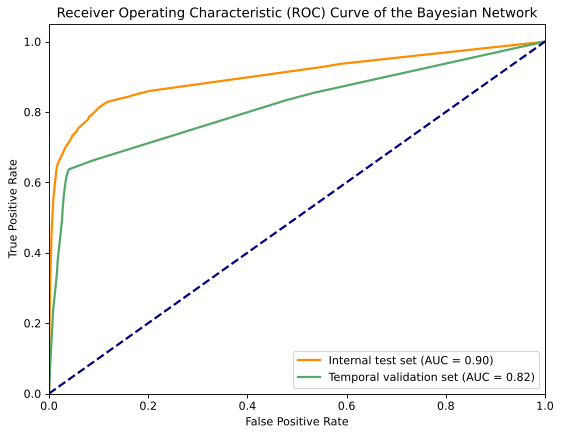

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
roc_rows = []
for label, y, p, c in [("Internal test set", y_test, p_test["Proposed BN"], "darkorange"),
                       ("Temporal validation set", y_val, p_val["Proposed BN"], "#55A868")]:
    fpr, tpr, thr = roc_curve(y, p)
    auc = roc_auc_score(y, p)
    ax.plot(fpr, tpr, color=c, lw=2, label=f"{label} (AUC = {auc:.2f})")
    roc_rows.append(pd.DataFrame({"set": label, "fpr": fpr, "tpr": tpr, "threshold": thr}))
ax.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Receiver Operating Characteristic (ROC) Curve of the Bayesian Network")
ax.legend(loc="lower right")
plt.savefig(f"{FIG_DIR}/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()
pd.concat(roc_rows).to_csv(f"{RESULTS_DIR}/roc_points_BN.csv", index=False)

## 9. Probabilistic inference examples
The proposed network was fitted on SMOTE-balanced data, so its posterior probabilities assume equal numbers of positive and negative cases. The same queries are also run on the network fitted to the original (unbalanced) training data, whose probabilities reflect the real proportion of positives in the development period.

In [18]:
bn, bn0 = fitted["Proposed BN"], fitted["BN without SMOTE"]
infer, infer0 = VariableElimination(bn), VariableElimination(bn0)

evidence = {"cough": 1, "fever": 1, "sore_throat": 1}
query = infer.query(variables=[TARGET], evidence=evidence, show_progress=False)
print(query)
print("Same query, BN without SMOTE:")
print(infer0.query(variables=[TARGET], evidence=evidence, show_progress=False))
print("Active trail cough -> corona_result:", bn.is_dconnected("cough", TARGET))

+------------------+----------------------+
| corona_result    |   phi(corona_result) |
+==================+======================+
| corona_result(0) |               0.0186 |
+------------------+----------------------+
| corona_result(1) |               0.9814 |
+------------------+----------------------+
Same query, BN without SMOTE:
+------------------+----------------------+
| corona_result    |   phi(corona_result) |
+==================+======================+
| corona_result(0) |               0.1847 |
+------------------+----------------------+
| corona_result(1) |               0.8153 |
+------------------+----------------------+
Active trail cough -> corona_result: True


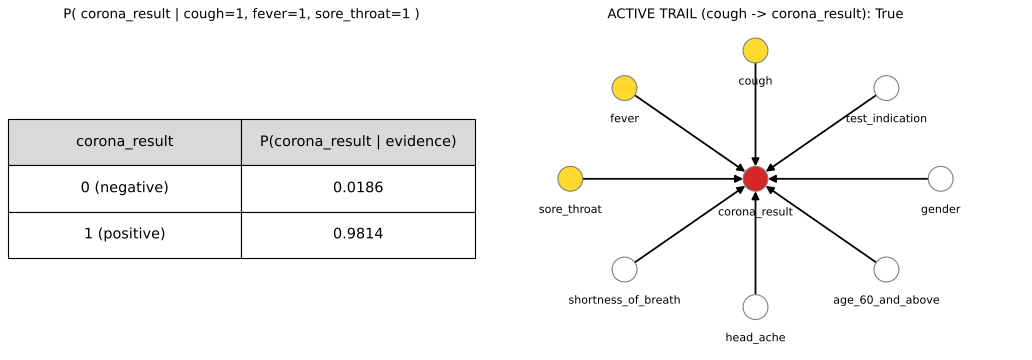

In [19]:
# Figure: query result (left) and network with the evidence nodes highlighted (right)
p0, p1 = query.get_value(**{TARGET: 0}), query.get_value(**{TARGET: 1})
fig, (axt, axg) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 1.15]})
axt.axis("off")
axt.set_title("P( corona_result | cough=1, fever=1, sore_throat=1 )", fontsize=12)
tab = axt.table(cellText=[["0 (negative)", f"{p0:.4f}"], ["1 (positive)", f"{p1:.4f}"]],
                colLabels=["corona_result", "P(corona_result | evidence)"],
                cellLoc="center", loc="center", colColours=["#D9D9D9", "#D9D9D9"])
tab.auto_set_font_size(False); tab.set_fontsize(13); tab.scale(1, 3)

G = nx.DiGraph(EDGES)
pos = {TARGET: (0, 0)}
pos.update({f: (np.cos(a), np.sin(a)) for f, a in zip(FEATURES, np.linspace(np.pi / 2, np.pi / 2 + 2 * np.pi, len(FEATURES), endpoint=False))})
node_col = ["#D62728" if n == TARGET else ("#FFD92F" if n in evidence else "white") for n in G.nodes]
nx.draw_networkx_edges(G, pos, ax=axg, arrows=True, arrowsize=14, width=1.6, node_size=500)
nx.draw_networkx_nodes(G, pos, ax=axg, node_color=node_col, edgecolors="grey", node_size=500)
for n, (xx, yy) in pos.items():
    axg.text(xx, yy - 0.2 if n != TARGET else yy - 0.22, n, ha="center", va="top", fontsize=10)
axg.set_title(f"ACTIVE TRAIL (cough -> corona_result): {bn.is_dconnected('cough', TARGET)}", fontsize=12)
axg.set_xlim(-1.45, 1.45); axg.set_ylim(-1.35, 1.2); axg.axis("off")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/inference_example.png", dpi=300, bbox_inches="tight")
plt.show()

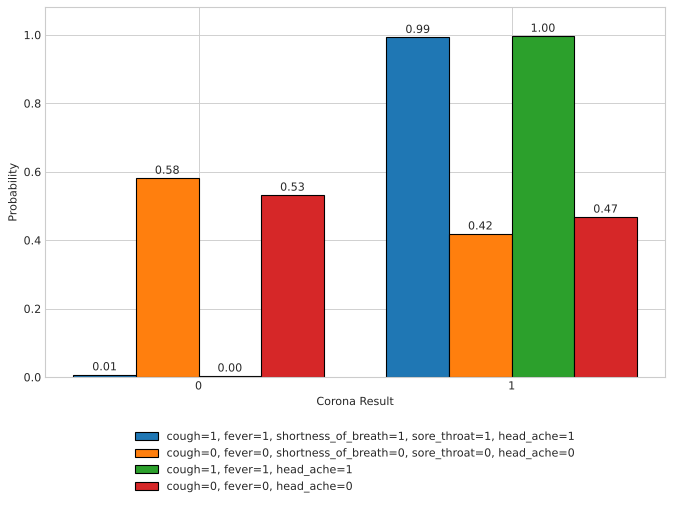

,evidence,P(positive) proposed BN (SMOTE),P(positive) BN without SMOTE
0,"cough=1, fever=1, shortness_of_breath=1, sore_...",0.9929,0.9418
1,"cough=0, fever=0, shortness_of_breath=0, sore_...",0.4186,0.0460
2,"cough=1, fever=1, head_ache=1",0.9964,0.9747
3,"cough=0, fever=0, head_ache=0",0.4679,0.0539
4,"cough=1, fever=1, sore_throat=1",0.9814,0.8153


In [20]:
EVIDENCE_SETS = [
    {"cough": 1, "fever": 1, "shortness_of_breath": 1, "sore_throat": 1, "head_ache": 1},
    {"cough": 0, "fever": 0, "shortness_of_breath": 0, "sore_throat": 0, "head_ache": 0},
    {"cough": 1, "fever": 1, "head_ache": 1},
    {"cough": 0, "fever": 0, "head_ache": 0},
    {"cough": 1, "fever": 1, "sore_throat": 1},
]
rows = []
for ev in EVIDENCE_SETS:
    rows.append({"evidence": ", ".join(f"{k}={v}" for k, v in ev.items()),
                 "P(positive) proposed BN (SMOTE)": infer.query([TARGET], evidence=ev, show_progress=False).get_value(**{TARGET: 1}),
                 "P(positive) BN without SMOTE": infer0.query([TARGET], evidence=ev, show_progress=False).get_value(**{TARGET: 1})})
inference_table = pd.DataFrame(rows)
inference_table.to_csv(f"{RESULTS_DIR}/inference_examples.csv", index=False)

# bar chart of the first four evidence sets (same sets as in the paper)
plt.style.use("seaborn-v0_8-whitegrid"); plt.rcParams["font.family"] = "DejaVu Sans"
fig, ax = plt.subplots(figsize=(10, 6))
w = 0.2; cols = ["#1F77B4", "#FF7F0E", "#2CA02C", "#D62728"]
for i, (r, c) in enumerate(zip(rows[:4], cols)):
    p1 = r["P(positive) proposed BN (SMOTE)"]
    vals = [1 - p1, p1]
    b = ax.bar(np.arange(2) + (i - 1.5) * w, vals, w, color=c, edgecolor="black", label=r["evidence"])
    for bb, v in zip(b, vals):
        ax.text(bb.get_x() + bb.get_width() / 2, v + 0.005, f"{v:.2f}", ha="center", va="bottom", fontsize=10)
ax.set_xticks([0, 1]); ax.set_xticklabels(["0", "1"])
ax.set_xlabel("Corona Result"); ax.set_ylabel("Probability"); ax.set_ylim(0, 1.08)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=1, fontsize=10, frameon=False)
plt.savefig(f"{FIG_DIR}/evidence_probabilities.png", dpi=300, bbox_inches="tight")
plt.show()
plt.style.use("default"); plt.rcParams["font.family"] = "DejaVu Sans"
inference_table.round(4)

## 10. Summary of the numbers used in the paper

In [21]:
bn_int, bn_val = internal["Proposed BN"], temporal["Proposed BN"]
summary = {
    "development records (ver_006)": len(dev_raw),
    "temporal validation records (ver_0083 after 30 Apr)": len(val_raw),
    "train records before SMOTE": len(X_train),
    "train records after SMOTE": len(X_sm),
    "internal test records": len(X_test),
    "temporal validation records used": len(X_val),
    "BN internal accuracy": bn_int["Accuracy"], "BN internal AUC": bn_int["AUC"],
    "BN temporal accuracy": bn_val["Accuracy"], "BN temporal AUC": bn_val["AUC"],
    "BN total time (s)": times["Proposed BN"]["total_s"], "RF total time (s)": times["Random Forest"]["total_s"],
    "P(positive | cough, fever, sore throat) SMOTE BN": query.get_value(**{TARGET: 1}),
}
pd.Series(summary).to_csv(f"{RESULTS_DIR}/summary.csv", header=["value"])
pd.Series(summary)

development records (ver_006)                          2.788480e+05
temporal validation records (ver_0083 after 30 Apr)    2.453378e+06
train records before SMOTE                             2.197610e+05
train records after SMOTE                              4.160120e+05
internal test records                                  5.494100e+04
temporal validation records used                       2.416058e+06
BN internal accuracy                                   9.127064e-01
BN internal AUC                                        9.010744e-01
BN temporal accuracy                                   9.340351e-01
BN temporal AUC                                        8.177110e-01
BN total time (s)                                      1.781545e-01
RF total time (s)                                      6.009205e+00
P(positive | cough, fever, sore throat) SMOTE BN       9.814265e-01
dtype: float64